In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity, mean_squared_error

Результат загрузки изображения:
Размер изображения: (470, 650)


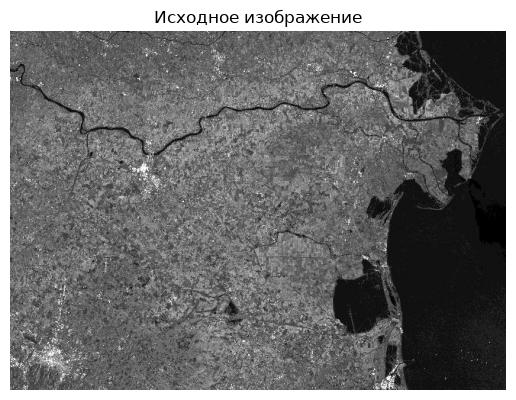

In [2]:
image_gray = cv2.imread('Desktop/sar_my_gray.jpg', cv2.IMREAD_GRAYSCALE)

print('Результат загрузки изображения:')
print('Размер изображения:', image_gray.shape)

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

Результат построения гистограммы:
Минимальная яркость: 0
Максимальная яркость: 255
Средняя яркость: 90.20772504091653


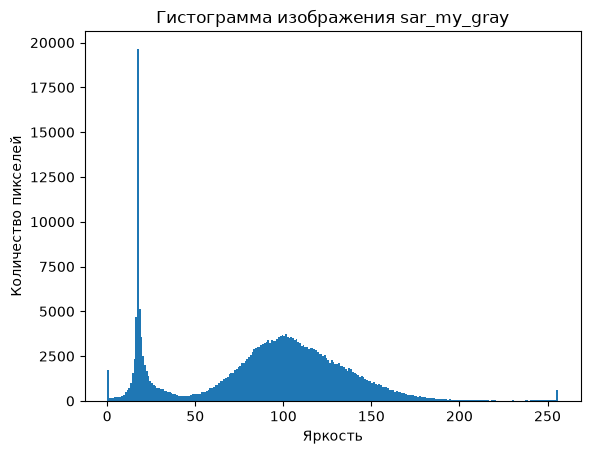

In [3]:
print('Результат построения гистограммы:')
print('Минимальная яркость:', image_gray.min())
print('Максимальная яркость:', image_gray.max())
print('Средняя яркость:', image_gray.mean())

plt.hist(image_gray.ravel(), bins=256, range=[0, 256])
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма изображения sar_my_gray')
plt.show()

Результат гамма-коррекции:
Gamma = 0.5 — изображение осветлено
Gamma = 2.0 — изображение затемнено


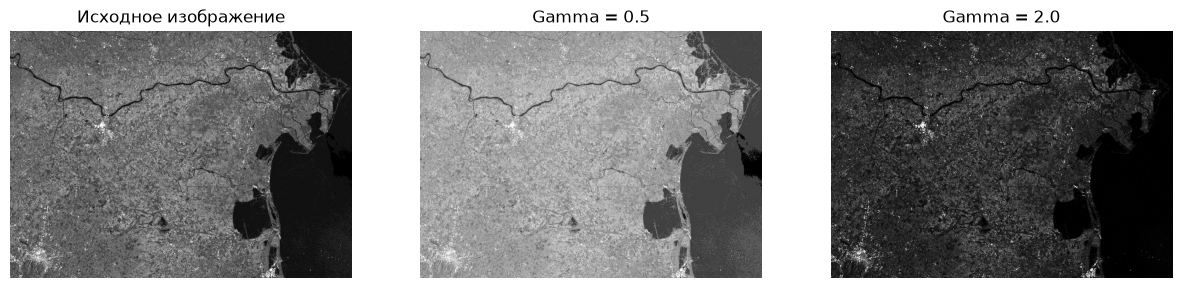

In [4]:
def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    corrected = corrected * 255
    return corrected.astype(np.uint8)

gamma_less_1 = gamma_correction(image_gray, 0.5)
gamma_more_1 = gamma_correction(image_gray, 2.0)

print('Результат гамма-коррекции:')
print('Gamma = 0.5 — изображение осветлено')
print('Gamma = 2.0 — изображение затемнено')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gamma_less_1, cmap='gray')
plt.title('Gamma = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_more_1, cmap='gray')
plt.title('Gamma = 2.0')
plt.axis('off')

plt.show()

In [5]:
mse_less_1 = mean_squared_error(image_gray, gamma_less_1)
ssim_less_1 = structural_similarity(image_gray, gamma_less_1)

mse_more_1 = mean_squared_error(image_gray, gamma_more_1)
ssim_more_1 = structural_similarity(image_gray, gamma_more_1)

print('Gamma = 0.5')
print('MSE:', mse_less_1)
print('SSIM:', ssim_less_1)

print()

print('Gamma = 2.0')
print('MSE:', mse_more_1)
print('SSIM:', ssim_more_1)

Gamma = 0.5
MSE: 3009.4844680851065
SSIM: 0.8080726687906928

Gamma = 2.0
MSE: 2887.806844517185
SSIM: 0.6076759986299123


In [6]:
mean_src = image_gray.mean()
std_src = image_gray.std()

eq_gray = cv2.equalizeHist(image_gray)

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

corrected_stat = (image_gray.astype(np.float32) - mean_src) / std_src
corrected_stat = corrected_stat * std_eq + mean_eq
corrected_stat = np.clip(corrected_stat, 0, 255).astype(np.uint8)

print('Статистика исходного изображения:')
print('Mean:', mean_src)
print('Std:', std_src)

print('\nСтатистика eq_gray:')
print('Mean:', mean_eq)
print('Std:', std_eq)

print('\nСтатистика после коррекции:')
print('Mean:', corrected_stat.mean())
print('Std:', corrected_stat.std())

Статистика исходного изображения:
Mean: 90.20772504091653
Std: 45.453554351354455

Статистика eq_gray:
Mean: 128.23331914893618
Std: 73.31815596599044

Статистика после коррекции:
Mean: 126.76331260229132
Std: 70.22961031968741


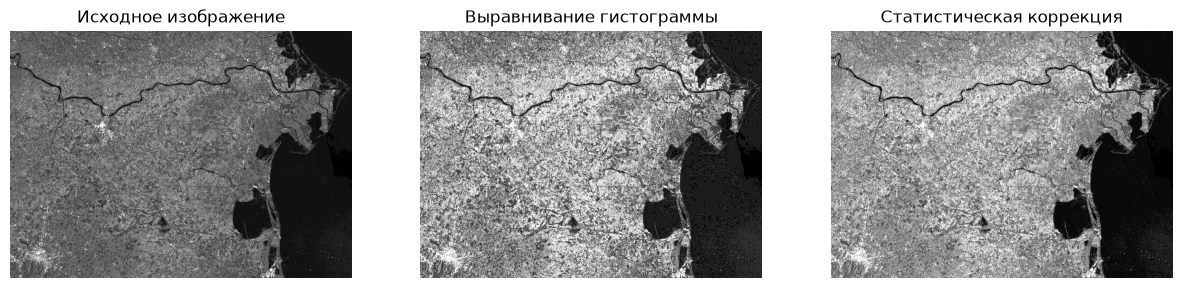

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Выравнивание гистограммы')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(corrected_stat, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')

plt.show()

Результат пороговой фильтрации: порог = 50
Результат пороговой фильтрации: порог = 100
Результат пороговой фильтрации: порог = 150
Результат пороговой фильтрации: порог = 200


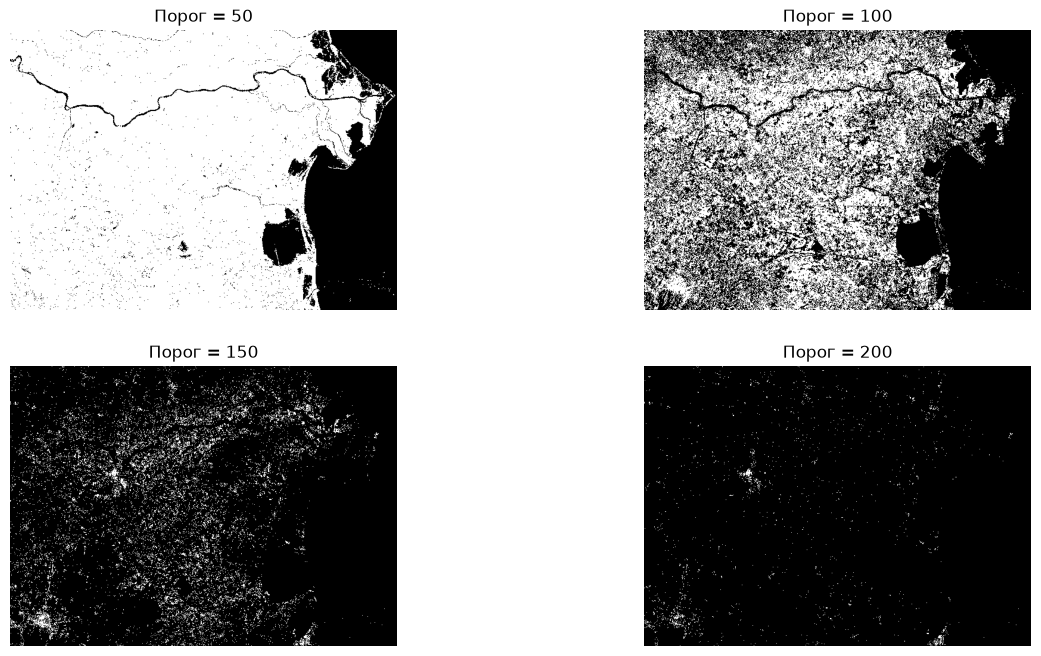

In [8]:
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(15, 8))

for i, threshold in enumerate(thresholds):
    _, binary = cv2.threshold(
        image_gray,
        threshold,
        255,
        cv2.THRESH_BINARY
    )

    print(f'Результат пороговой фильтрации: порог = {threshold}')
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Порог = {threshold}')
    plt.axis('off')

plt.show()